In [21]:
# imports

from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options

from bs4 import BeautifulSoup
import time
import urllib.request
import PIL
from IPython.display import display, Image
import matplotlib.pyplot as plt
import random
import numpy as np
from tqdm import tqdm
import requests
import random

from PIL import ImageEnhance

%matplotlib inline

### extract images from pinterest given a prompt

In [2]:
driver = None
DRIVER_LINK = "/Users/mcharit2/Desktop/Research/CompoSketch/composketch/chromedriver"

# if your driver is the incorrect version, https://googlechromelabs.github.io/chrome-for-testing/ or https://github.com/dreamshao/chromedriver  for older version

def make_driver(ref="https://www.pinterest.com/"):
    global driver
    chrome_options = Options()
    s = Service(DRIVER_LINK)

    #chrome_options.add_extension("adblocker.crx")       # add adblocker

    driver = webdriver.Chrome(service=s, options=chrome_options)
    # Enable Network and set extra HTTP headers
    driver.execute_cdp_cmd('Network.enable', {})
    driver.execute_cdp_cmd('Network.setExtraHTTPHeaders', {
        'headers': {
            'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/134.0.0.0 Safari/537.36',
            'Referer':ref,
            'Accept-Language': 'en-US,en;q=0.9',
        }
    })

    time.sleep(1)  # wait for the driver to initialize

    # IGNORE ADDBLOCK TABS
    driver.switch_to.window(driver.window_handles[0]) # switch to the main tab

make_driver()

In [3]:
#retrieve the body content from a link
def getLinkSoup(link=None,wait_time=1,scroll=0):
    global driver
    if link:
        driver.get(link)
        time.sleep(wait_time) #if you want to wait 1 seconds for the page to load
    for i in range(scroll):
        driver.execute_script(f"window.scrollTo(1,{250*(i+1)})")
        time.sleep(wait_time//2)
    # time.sleep(wait_time)

    response = driver.page_source
    soup = BeautifulSoup(response, 'html.parser')
    return soup

#retrieve the body content from a link without using selenium
def quickLinkSoup(link):
    response = requests.get(
        url=link,
        headers = {'User-Agent':'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/102.0.0.0 Safari/537.36'}
    )
    if response.status_code != 200:
        print(f"> ERROR: Link [{link}] not found... (Response: {response.status_code})")
        return None
    soup = BeautifulSoup(response.content, 'html.parser')
    return soup


In [4]:
# returns images from a pinterest query
def getPins(query="",ratio=0,wait_time=2.5,scroll=5):
    global driver
    if query:
        fix_query = query.replace(" ","%20")
        link = "https://www.pinterest.com/search/pins/?q="+fix_query
    else:   # use homepage if no query
        link = "https://www.pinterest.com/"

    driver.get(link)
    time.sleep(wait_time)

    #get soup
    all_imgs = set()
    for i in range(scroll):
        print(f"Scrolling... ({i+1}/{scroll})")

        # scroll down to load more images
        driver.execute_script(f"window.scrollTo(1,{250*(i+1)})")
        time.sleep(wait_time//2)

        # get soup and image links
        response = driver.page_source
        soup = BeautifulSoup(response, 'html.parser')

        # grab all the image links and add to set
        print("Images found on page: {}".format(len(soup.find_all('img'))))
        img_links = [i.get('src') for i in soup.find_all('img')]
        print(f"{len(img_links)} images found".format(len(img_links)))
        all_imgs.update(img_links)
        print(f"{len(all_imgs)} unique images found so far".format(len(all_imgs)))

        # wait
        time.sleep(wait_time) # wait before next scroll

    #go through each image and get the data
    pil_imgs = []
    for l in tqdm(all_imgs, desc="Extracted images"):
        try:
            #if the image is within the ratio, save it
            im = PIL.Image.open(urllib.request.urlopen(l))
            if im.size[0] < 200 or im.size[1] < 200:
                continue

            im_ratio = im.size[0]/im.size[1]
            if ratio == 0 or abs(im_ratio-ratio) <= 0.4:
                pil_imgs.append([im,im_ratio])
        except Exception as e:
            print("error: ",e)
            pass

    return pil_imgs

In [5]:
# wait for sign in on pinterest before running the rest
getLinkSoup("https://www.pinterest.com/")
input("Sign in to Pinterest and scroll to load more images, then press Enter to continue...")

''

In [6]:
# show the image set from a query
imgs = getPins("aesthetic")
print(len(imgs))

Scrolling... (1/5)
Images found on page: 45
45 images found
45 unique images found so far
Scrolling... (2/5)
Images found on page: 50
50 images found
50 unique images found so far
Scrolling... (3/5)
Images found on page: 49
49 images found
55 unique images found so far
Scrolling... (4/5)
Images found on page: 53
53 images found
60 unique images found so far
Scrolling... (5/5)
Images found on page: 49
49 images found
62 unique images found so far


Extracted images: 100%|██████████| 62/62 [00:02<00:00, 22.58it/s]

37


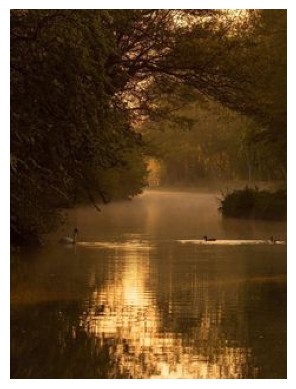

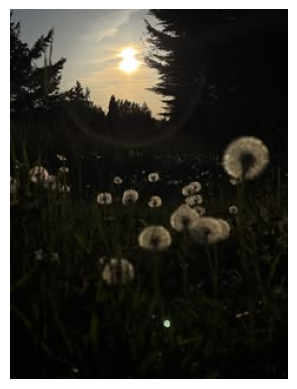

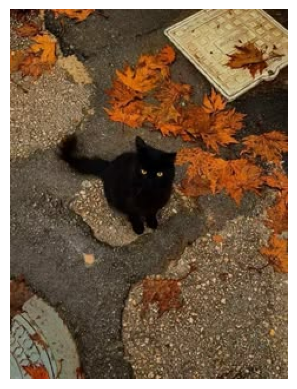

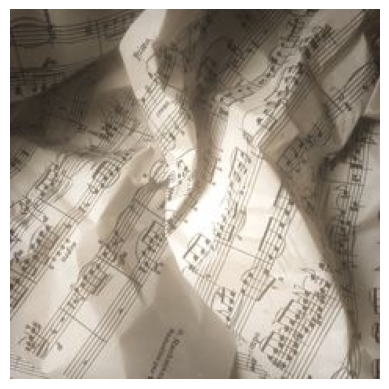

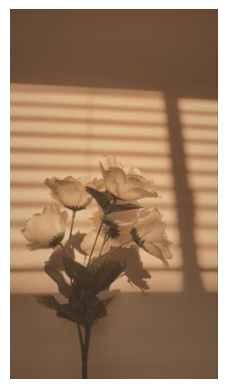

<Figure size 640x480 with 0 Axes>

In [7]:
for i in random.sample(imgs,k=5):
# for i in imgs[]:
    plt.imshow(i[0])
    # plt.title(f"{i[1]:.2f}")
    plt.axis('off')
    plt.figure()

## Create a set of good images and bad images

In [8]:
# good dataset
good_imgs = getPins("",0,2.5,100)

Scrolling... (1/100)
Images found on page: 23
23 images found
23 unique images found so far
Scrolling... (2/100)
Images found on page: 28
28 images found
28 unique images found so far
Scrolling... (3/100)
Images found on page: 25
25 images found
31 unique images found so far
Scrolling... (4/100)
Images found on page: 26
26 images found
37 unique images found so far
Scrolling... (5/100)
Images found on page: 23
23 images found
38 unique images found so far
Scrolling... (6/100)
Images found on page: 42
42 images found
59 unique images found so far
Scrolling... (7/100)
Images found on page: 41
41 images found
64 unique images found so far
Scrolling... (8/100)
Images found on page: 41
41 images found
68 unique images found so far
Scrolling... (9/100)
Images found on page: 41
41 images found
72 unique images found so far
Scrolling... (10/100)
Images found on page: 40
40 images found
77 unique images found so far
Scrolling... (11/100)
Images found on page: 41
41 images found
79 unique images

Extracted images: 100%|██████████| 474/474 [01:06<00:00,  7.16it/s]


In [19]:
def extend_side(im,side,amount):
    # majority_color = 255
    #majority_color = im.resize((1,1)).getpixel((0,0))
    # use random color from image as majority color
    majority_color = random.choice(im.getdata())
    if side == "left":
        new_im = PIL.Image.new(im.mode, (im.size[0]+amount, im.size[1]), majority_color)
        new_im.paste(im, (amount, 0))
    elif side == "right":
        new_im = PIL.Image.new(im.mode, (im.size[0]+amount, im.size[1]), majority_color)
        new_im.paste(im, (0, 0))
    elif side == "top":
        new_im = PIL.Image.new(im.mode, (im.size[0], im.size[1]+amount), majority_color)
        new_im.paste(im, (0, amount))
    elif side == "bottom":
        new_im = PIL.Image.new(im.mode, (im.size[0], im.size[1]+amount), majority_color)
        new_im.paste(im, (0, 0))
    return new_im

def random_crop(im):
    new_win_dim = (random.randint(im.size[0]//3,im.size[0]), random.randint(im.size[1]//3,im.size[1]))
    # apply random crop to random position
    x1 = random.randint(0, im.size[0] - new_win_dim[0])
    y1 = random.randint(0, im.size[1] - new_win_dim[1])
    x2 = x1 + new_win_dim[0]
    y2 = y1 + new_win_dim[1]
    
    return im.crop((x1, y1, x2, y2))

def change_contrast(im):
    # randomly change contrast by a factor of 0.5 to 1.5
    factor = random.uniform(0.5, 1.5)
    enhancer = ImageEnhance.Contrast(im)
    return enhancer.enhance(factor)

def rotate_image(im):
    # randomly rotate image by 0 to 360 degrees
    angle = random.randint(0, 360)
    return im.rotate(angle)

def brightness(im):
    # randomly change brightness by a factor of 0.5 to 1.5
    factor = random.uniform(5, 7)
    enhancer = ImageEnhance.Brightness(im)
    return enhancer.enhance(factor)


def random_augment(im):
    # randomly apply one of the augmentations
    aug = random.choice([extend_side, random_crop, change_contrast, rotate_image, brightness])
    if aug == extend_side:
        side = random.choice(["left", "right", "top", "bottom"])
        amount = random.randint(10, 100)
        return extend_side(im,side,amount)
    else:
        return aug(im)

In [12]:
# reimport good images from peakmodel_dataset/good
import os

if not good_imgs or len(good_imgs) == 0:
    good_imgs = []
    for i in os.listdir("peakmodel_dataset/good"):
        try:
            im = PIL.Image.open("peakmodel_dataset/good/"+i)
            good_imgs.append([im,im.size[0]/im.size[1]])
        except Exception as e:
            print("error: ",e)
            pass

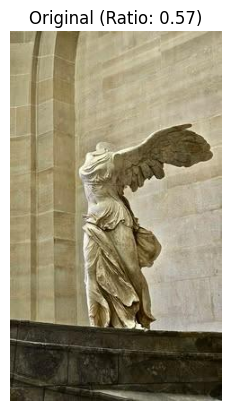

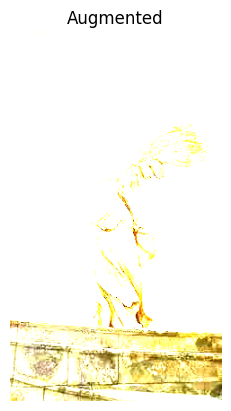

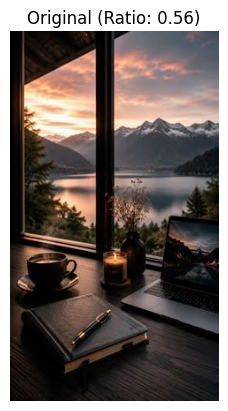

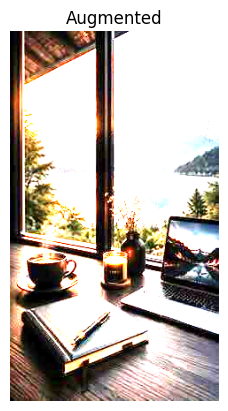

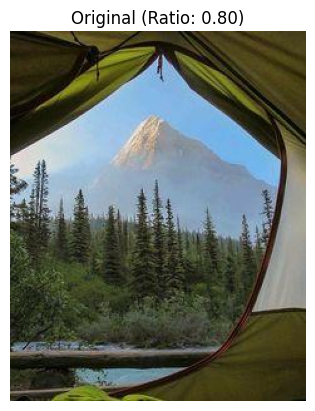

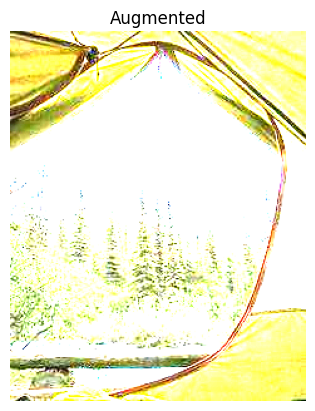

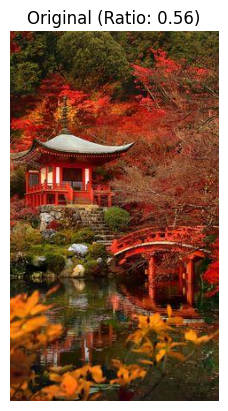

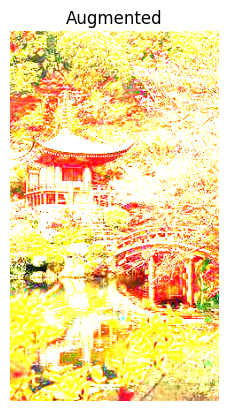

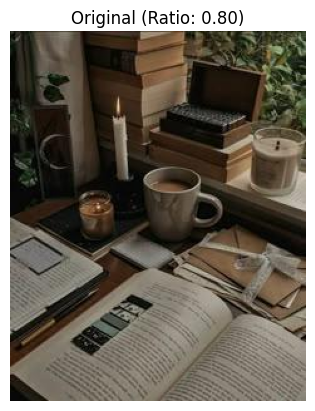

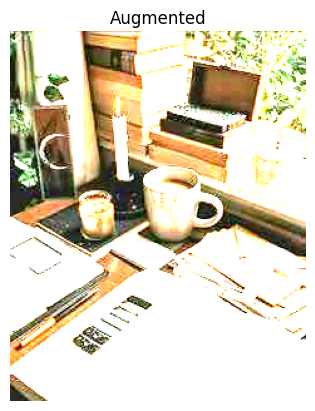

<Figure size 640x480 with 0 Axes>

In [23]:
%matplotlib inline
# show before and after augmentation
for i in random.sample(good_imgs,k=5):
    plt.imshow(i[0])
    plt.title(f"Original (Ratio: {i[1]:.2f})")
    plt.axis('off')
    plt.figure()

    aug_im = brightness(i[0])
    plt.imshow(aug_im)
    plt.title("Augmented")
    plt.axis('off')
    plt.figure()

In [15]:
len(good_imgs)

449

In [24]:
# bad dataset - extend a side or crop it poorly
bad_imgs = []
shuffled_imgs = random.sample(good_imgs, k=len(good_imgs))
for im in shuffled_imgs:
    # randomly augment the image
    bad_imgs.append([random_augment(im[0]),im[1]])

    # extend a random side by 20-50 pixels
    # l_ = min(im[0].size)
    # for side in ["left","right","top","bottom"]:
    #     amount = random.randint(l_//5,l_//3)
    #     bad_imgs.append([extend_side(im[0],side,amount),im[1]])

    # # crop a random amount from each side (up to 30 pixels)
    # for _ in range():
    #     bad_imgs.append([random_crop(im[0]),im[1]])

    # # change contrast randomly
    # for _ in range(4):
    #     bad_imgs.append([change_contrast(im[0]),im[1]])

    # # rotate randomly
    # for _ in range(4):
    #     bad_imgs.append([rotate_image(im[0]),im[1]])

    # # change brightness randomly
    # for _ in range(4):
    #     bad_imgs.append([brightness(im[0]),im[1]])


/var/folders/n4/ztbcwq6n25947kmq8sjw2v180000gp/T/ipykernel_45436/3754372857.py:5: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  majority_color = random.choice(im.getdata())


In [25]:
import numpy as np
import os

# export the datasets to peakmodel_dataset/good and peakmodel_dataset/bad folders
def save_dataset(imgs,folder,name=""):
    os.makedirs(folder, exist_ok=True)
    for i,im in enumerate(imgs):
        im[0].save(os.path.join(folder,f"{name}_{i}.jpg"))

save_dataset(good_imgs,"peakmodel_dataset/good", "good")
save_dataset(bad_imgs,"peakmodel_dataset/bad", "bad")

# export to pickle
import pickle
with open("peak-good_imgs.pkl", "wb") as f:
    pickle.dump(good_imgs, f)
with open("peak-bad_imgs.pkl", "wb") as f:
    pickle.dump(bad_imgs, f)

## Classification Model - Peak Model

In [26]:
"""
Image Quality Classifier
Trains a binary classifier: 1 = good image, 0 = bad image (cropped/padded).

Directory structure expected:
    dataset/
        good/   ← images labeled 1
        bad/    ← images labeled 0
"""

import os
from pathlib import Path
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models, transforms
from torchvision.models import EfficientNet_B0_Weights

# ── Config ────────────────────────────────────────────────────────────────────
DATASET_DIR = "peakmodel_dataset"          # root folder with good/ and bad/ subfolders
IMG_SIZE    = 224                # all images resized to this
BATCH_SIZE  = 32
EPOCHS      = 15
LR          = 1e-4
VAL_SPLIT   = 0.2
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
SAVE_PATH   = "peak_model.pt"
# ─────────────────────────────────────────────────────────────────────────────


def get_transforms():
    """
    Augment heavily — the dataset is varied and bad images differ only in
    geometric distortions, so spatial augmentation helps generalisation.
    """
    train_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),     # handle random input sizes
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        transforms.RandomAffine(degrees=10, translate=(0.05, 0.05)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],  # ImageNet stats
                             [0.229, 0.224, 0.225]),
    ])
    val_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])
    return train_tf, val_tf


def build_model(num_classes=2):
    """EfficientNet-B0 pretrained on ImageNet, head replaced for binary task."""
    model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, num_classes),
    )
    return model


def load_datasets(root, train_tf, val_tf):
    """
    ImageFolder expects:
        root/good/  → class index 0  (may differ by sort order)
        root/bad/   → class index 1
    We remap so that good=1 and bad=0 regardless of folder sort order.
    """
    full_ds = datasets.ImageFolder(root, transform=train_tf)

    # Remap class indices: good→1, bad→0
    class_to_idx = full_ds.class_to_idx          # e.g. {'bad': 0, 'good': 1}
    print(f"Classes found: {class_to_idx}")
    good_idx = class_to_idx.get("good", 1)
    bad_idx  = class_to_idx.get("bad",  0)
    if good_idx != 1 or bad_idx != 0:
        # Remap targets in-place
        remap = {good_idx: 1, bad_idx: 0}
        full_ds.targets = [remap[t] for t in full_ds.targets]
        full_ds.class_to_idx = {"bad": 0, "good": 1}

    # Train / val split
    n_val   = int(len(full_ds) * VAL_SPLIT)
    n_train = len(full_ds) - n_val
    train_ds, val_ds = random_split(
        full_ds, [n_train, n_val],
        generator=torch.Generator().manual_seed(42),
    )

    # Give val its own (non-augmented) transform
    val_ds.dataset = datasets.ImageFolder(root, transform=val_tf)
    val_ds.dataset.targets = full_ds.targets      # keep remapped labels
    val_ds.dataset.class_to_idx = full_ds.class_to_idx

    return train_ds, val_ds


def train():
    train_tf, val_tf = get_transforms()
    train_ds, val_ds = load_datasets(DATASET_DIR, train_tf, val_tf)
    print(f"Train: {len(train_ds)} samples | Val: {len(val_ds)} samples")

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=4, pin_memory=True)

    model     = build_model().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_val_acc = 0.0

    for epoch in range(1, EPOCHS + 1):
        # ── Train ──────────────────────────────────────────────────────────
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += imgs.size(0)

        train_loss = total_loss / total
        train_acc  = correct / total

        # ── Validate ───────────────────────────────────────────────────────
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                preds = model(imgs).argmax(1)
                val_correct += (preds == labels).sum().item()
                val_total   += imgs.size(0)

        val_acc = val_correct / val_total
        scheduler.step()

        print(f"Epoch {epoch:02d}/{EPOCHS} | "
              f"Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.3f} | "
              f"Val Acc: {val_acc:.3f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), SAVE_PATH)
            print(f"  ✓ Saved best model (val acc {val_acc:.3f})")

    print(f"\nTraining complete. Best val accuracy: {best_val_acc:.3f}")
    print(f"Model saved to: {SAVE_PATH}")


# ── Inference helper ──────────────────────────────────────────────────────────

def predict(image_path: str, model_path: str = SAVE_PATH) -> dict:
    """
    Predict whether a single image is good (1) or bad (0).
    Works on images of any size.
    """
    from PIL import Image

    _, val_tf = get_transforms()
    model = build_model().to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    img    = Image.open(image_path).convert("RGB")
    tensor = val_tf(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).squeeze()

    label = int(probs.argmax().item())
    return {
        "label":       label,
        "prediction":  "good" if label == 1 else "bad",
        "confidence":  round(probs[label].item(), 4),
        "prob_good":   round(probs[1].item(), 4),
        "prob_bad":    round(probs[0].item(), 4),
    }

In [27]:
train()

Classes found: {'bad': 0, 'good': 1}
Train: 719 samples | Val: 179 samples


/Users/mcharit2/Desktop/Research/CompoSketch/composketch/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/15 | Loss: 0.6917 | Train Acc: 0.561 | Val Acc: 0.570
  ✓ Saved best model (val acc 0.570)
Epoch 02/15 | Loss: 0.6498 | Train Acc: 0.637 | Val Acc: 0.587
  ✓ Saved best model (val acc 0.587)
Epoch 03/15 | Loss: 0.5947 | Train Acc: 0.684 | Val Acc: 0.615
  ✓ Saved best model (val acc 0.615)
Epoch 04/15 | Loss: 0.5575 | Train Acc: 0.732 | Val Acc: 0.637
  ✓ Saved best model (val acc 0.637)
Epoch 05/15 | Loss: 0.5233 | Train Acc: 0.723 | Val Acc: 0.670
  ✓ Saved best model (val acc 0.670)
Epoch 06/15 | Loss: 0.4935 | Train Acc: 0.755 | Val Acc: 0.682
  ✓ Saved best model (val acc 0.682)
Epoch 07/15 | Loss: 0.4436 | Train Acc: 0.796 | Val Acc: 0.693
  ✓ Saved best model (val acc 0.693)
Epoch 08/15 | Loss: 0.4275 | Train Acc: 0.786 | Val Acc: 0.715
  ✓ Saved best model (val acc 0.715)
Epoch 09/15 | Loss: 0.3978 | Train Acc: 0.832 | Val Acc: 0.743
  ✓ Saved best model (val acc 0.743)
Epoch 10/15 | Loss: 0.3825 | Train Acc: 0.818 | Val Acc: 0.732
Epoch 11/15 | Loss: 0.3709 | Train Ac

In [30]:
predict("imgs/test-imgs/mountain.jpg", "peak_model.pt")

{'label': 1,
 'prediction': 'good',
 'confidence': 0.808,
 'prob_good': 0.808,
 'prob_bad': 0.192}